In [4]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT / "src"))
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "main_with_exo_2.csv"
TARGET = "GBP-CNY"

## Data Loading and Preprocessing

In [5]:
from fx_forecasting.data.load import load_fx_csv
from fx_forecasting.data.preprocess import prepare_fx_data
from fx_forecasting.data.inspect import inspect_data

df = load_fx_csv(DATA_PATH, date_col='Date')

# Inspect Data
inspect_data(df)



Shape: (2779, 17)

Columns:
['timestamp', 'GBP-CNY', 'GBP-USD', 'GBP-EUR', 'GBP-JPY', 'GBP-KRW', 'GBP-CHF', 'ftse100_Close', 'gold_price', 'DTWEXBGS', 'DGS10', 'DCOILBRENTEU', 'vix_daily_close', 'glc_nominal_2', 'glc_nominal_10', 'ois_1', 'ois_2']

First rows:
   timestamp  GBP-CNY  GBP-USD  GBP-EUR   GBP-JPY    GBP-KRW  GBP-CHF  \
0 2015-01-02   9.5476   1.5388   1.2790  184.9638  1702.0821   1.5373   
1 2015-01-05   9.4794   1.5240   1.2767  182.2552  1690.7256   1.5338   
2 2015-01-06   9.4244   1.5170   1.2727  180.0831  1670.4901   1.5287   
3 2015-01-07   9.3582   1.5063   1.2762  179.9275  1661.7351   1.5327   
4 2015-01-08   9.3724   1.5082   1.2789  180.5014  1654.6764   1.5363   

   ftse100_Close  gold_price  DTWEXBGS  DGS10  DCOILBRENTEU  vix_daily_close  \
0    6547.799805      760.79  102.9027   2.12         55.38        17.790001   
1    6417.200195      788.02  103.4976   2.04         51.08        19.920000   
2    6366.500000      797.16  103.2938   1.97         50.12 

In [6]:

# Assume LSTM model
X_train, y_train, X_test, y_test, scaler, feature_columns = prepare_fx_data(
    df,
    target_col=TARGET,
    test_ratio=0.2,
    add_returns=True,
    add_ma=False,
    add_volatility=False,
    scale=True,
    scaler_type="standard",
    make_windows=True,
    lookback=30
)

# feature_columns = [c for c in columns if c != TARGET]

print(feature_columns)


/Users/apple/opt/miniconda3/envs/torchenv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/apple/opt/miniconda3/envs/torchenv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/apple/opt/miniconda3/envs/torchenv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


ValueError: Input X contains infinity or a value too large for dtype('float64').

Shape: (2779, 7)

Columns:
['timestamp', 'GBP-CNY', 'GBP-USD', 'GBP-EUR', 'GBP-JPY', 'GBP-KRW', 'GBP-CHF']

First rows:
   timestamp  GBP-CNY  GBP-USD  GBP-EUR   GBP-JPY    GBP-KRW  GBP-CHF
0 2015-01-02   9.5476   1.5388   1.2790  184.9638  1702.0821   1.5373
1 2015-01-05   9.4794   1.5240   1.2767  182.2552  1690.7256   1.5338
2 2015-01-06   9.4244   1.5170   1.2727  180.0831  1670.4901   1.5287
3 2015-01-07   9.3582   1.5063   1.2762  179.9275  1661.7351   1.5327
4 2015-01-08   9.3724   1.5082   1.2789  180.5014  1654.6764   1.5363

Data types:
timestamp    datetime64[us]
GBP-CNY             float64
GBP-USD             float64
GBP-EUR             float64
GBP-JPY             float64
GBP-KRW             float64
GBP-CHF             float64
dtype: object

Missing values:
timestamp    0
GBP-CNY      0
GBP-USD      0
GBP-EUR      0
GBP-JPY      0
GBP-KRW      0
GBP-CHF      0
dtype: int64

Date range:
Start: 2015-01-02 00:00:00
End: 2025-12-31 00:00:00

Observed time gaps:
timestamp
1 days

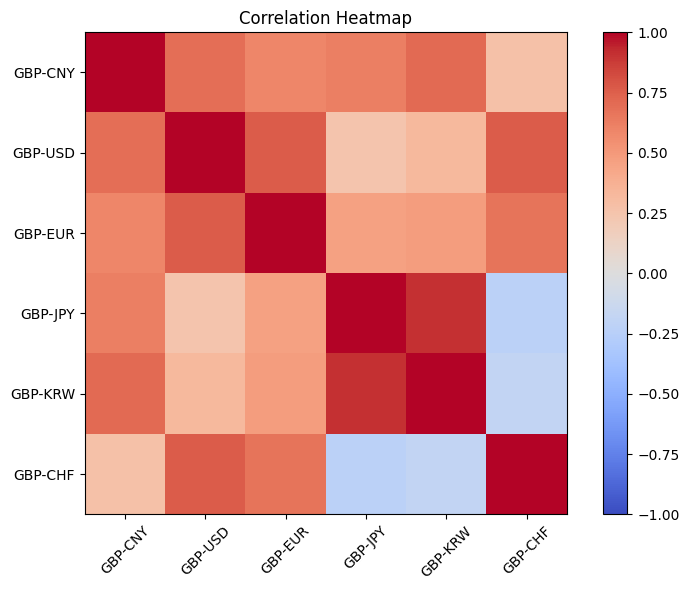

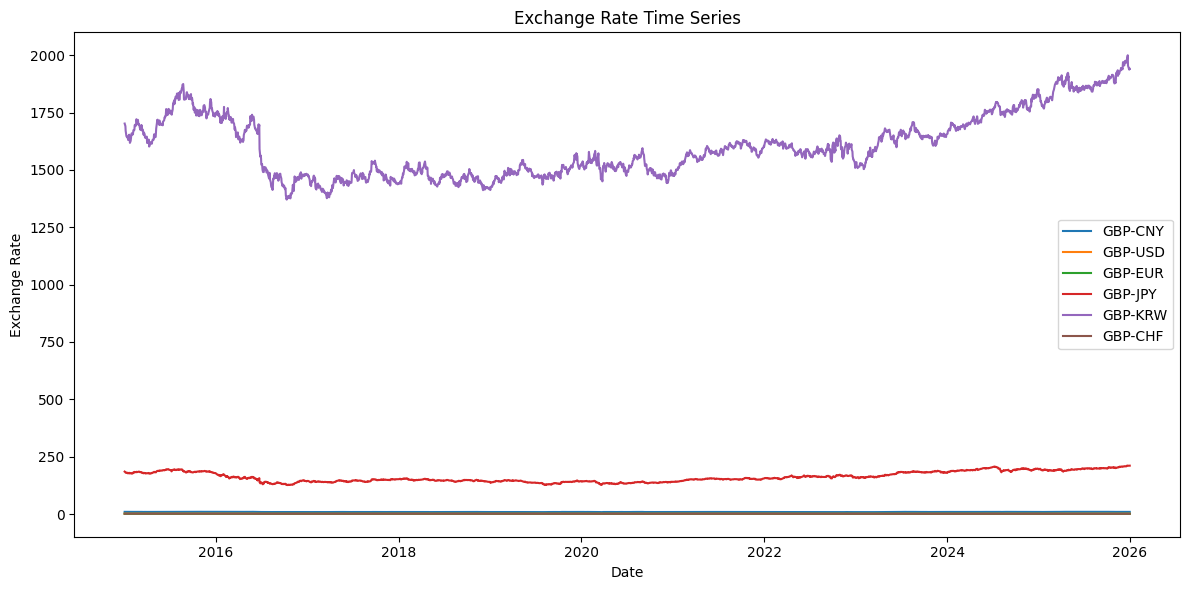

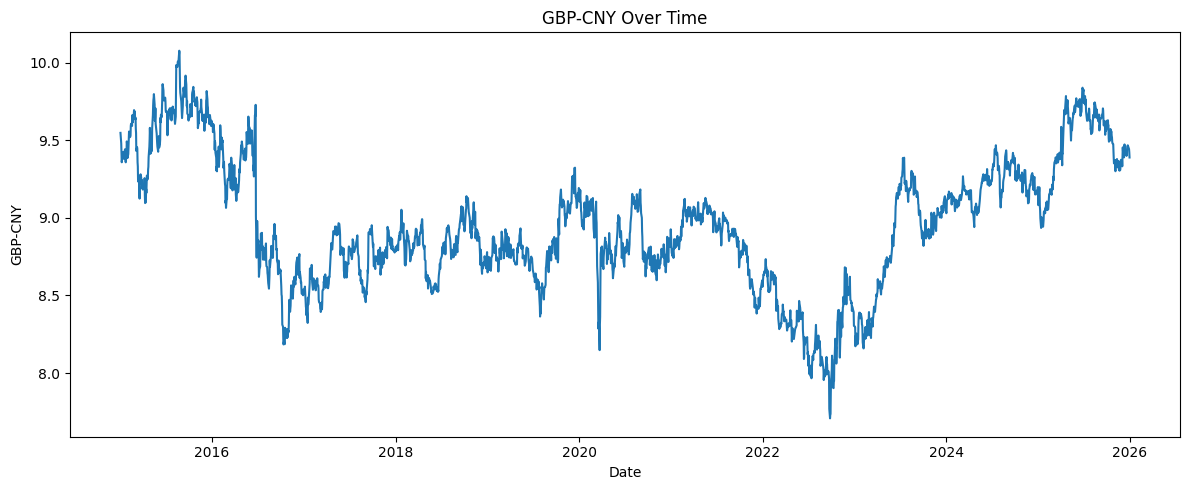

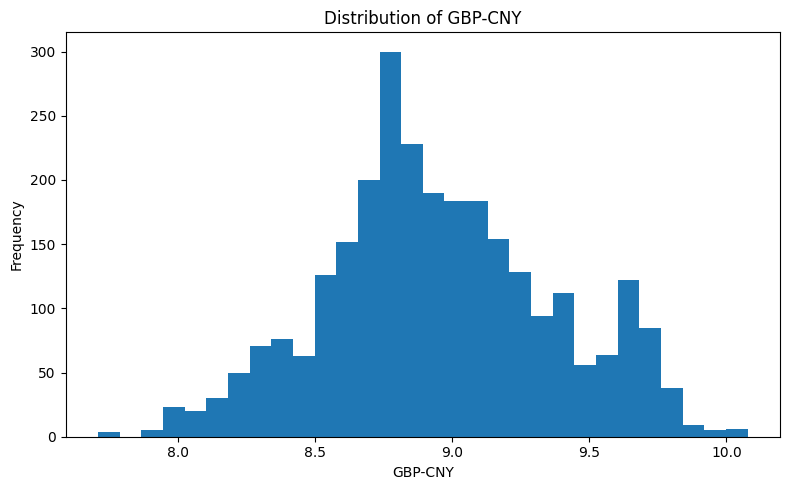

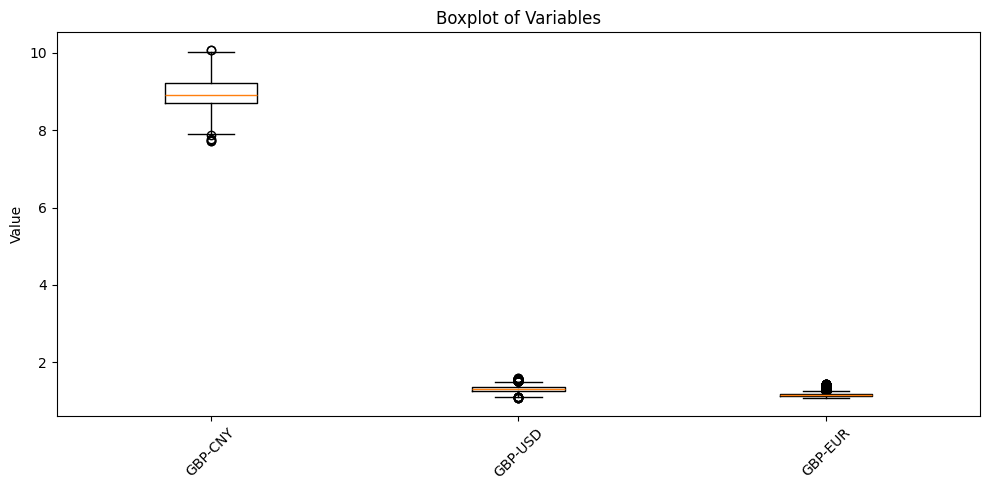

In [ ]:
# visualisations

from fx_forecasting.visualization.plots import (
    plot_all_series,
    plot_target_series,
    plot_histogram,
    plot_boxplot,
    plot_correlation_heatmap
)

plot_correlation_heatmap(df)
plot_all_series(df)
plot_target_series(df, TARGET)
plot_histogram(df, TARGET)
plot_boxplot(df, cols=feature_columns[:3])

## Model Training

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

# Hyperparameters
HIDDEN_DIM = 64
NUM_LAYERS = 2
LR = 0.001
EPOCHS = 50
BATCH_SIZE = 64


In [ ]:
# Data loaders
from torch.utils.data import TensorDataset, DataLoader

# convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# datasets
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_test_t, y_test_t)

# dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
from fx_forecasting.models.baseline import DeterministicLSTM
from fx_forecasting.training.train import train_model


model = DeterministicLSTM(
    input_dim=X_train.shape[-1],
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS
)

# Optimizer and loss
optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss() 
device = "cuda" if torch.cuda.is_available() else "cpu"

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=EPOCHS,
    device=device,
    save_path="best_baseline_model.pt",
    early_stopping_patience=5
)

Epoch 1/50 [Val]: 100%|██████████| 9/9 [00:00<00:00, 191.87it/s]


Epoch 1/50 | Train Loss: 0.4864 | Val Loss: 0.1589 | Train MAE: 0.5093 | Val MAE: 0.2874 | Train RMSE: 0.6632 | Val RMSE: 0.3251
Saved best model at epoch 1 with val loss 0.1589


Epoch 2/50 [Val]: 100%|██████████| 9/9 [00:00<00:00, 176.70it/s]


Epoch 2/50 | Train Loss: 0.0612 | Val Loss: 0.0832 | Train MAE: 0.1829 | Val MAE: 0.2328 | Train RMSE: 0.2416 | Val RMSE: 0.2609
Saved best model at epoch 2 with val loss 0.0832


Epoch 3/50 [Val]: 100%|██████████| 9/9 [00:00<00:00, 165.76it/s]


...

Epoch 23/50 | Train Loss: 0.0186 | Val Loss: 0.0342 | Train MAE: 0.1019 | Val MAE: 0.1403 | Train RMSE: 0.1347 | Val RMSE: 0.1663


Epoch 24/50 [Val]: 100%|██████████| 9/9 [00:00<00:00, 201.23it/s]


Epoch 24/50 | Train Loss: 0.0181 | Val Loss: 0.0305 | Train MAE: 0.1000 | Val MAE: 0.1318 | Train RMSE: 0.1325 | Val RMSE: 0.1576


Epoch 25/50 [Val]: 100%|██████████| 9/9 [00:00<00:00, 211.72it/s]

Epoch 25/50 | Train Loss: 0.0182 | Val Loss: 0.0321 | Train MAE: 0.1008 | Val MAE: 0.1319 | Train RMSE: 0.1323 | Val RMSE: 0.1568
Early stopping at epoch 25
Best model was from epoch 20 with val loss 0.0286


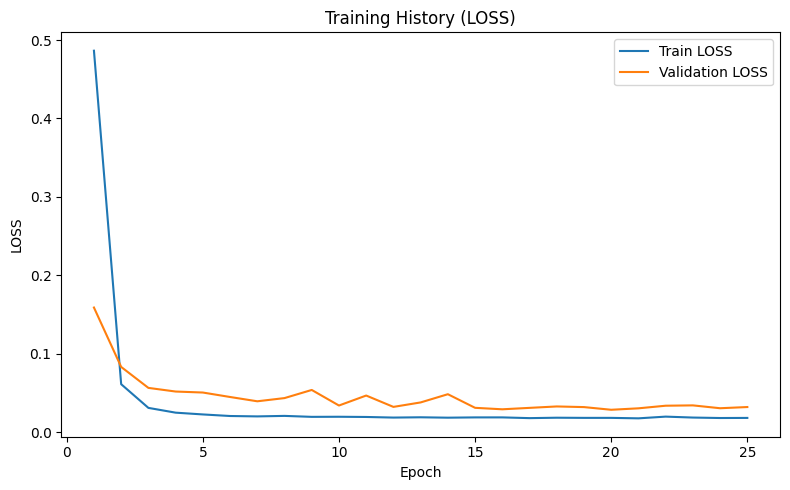

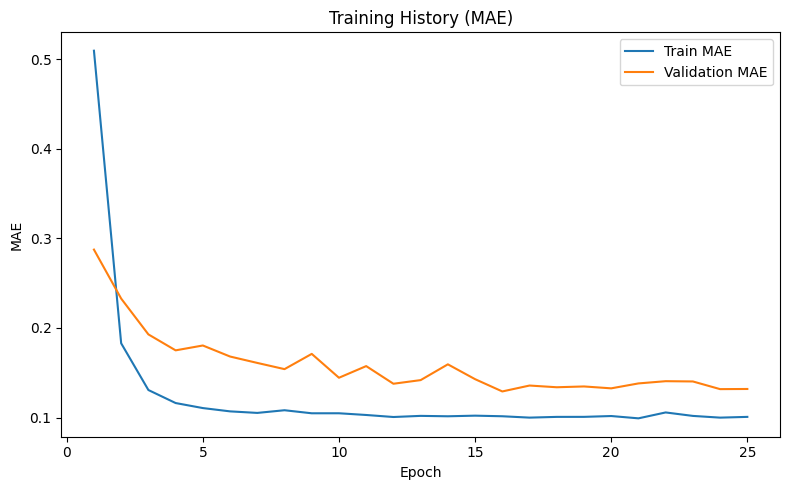

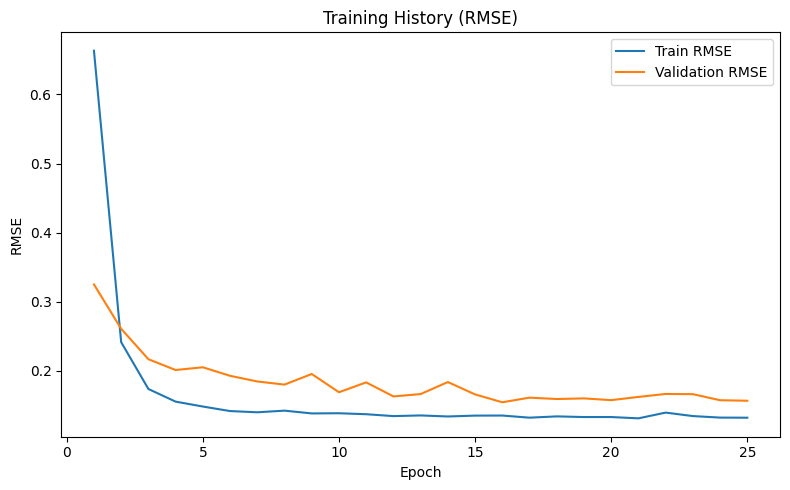

In [ ]:
from fx_forecasting.visualization.plots import plot_training_history

plot_training_history(history, metric="loss")
plot_training_history(history, metric="mae")
plot_training_history(history, metric="rmse")

## Evaluation 


Evaluation metrics:
MSE: 0.034043
RMSE: 0.184508
MAE: 0.136239


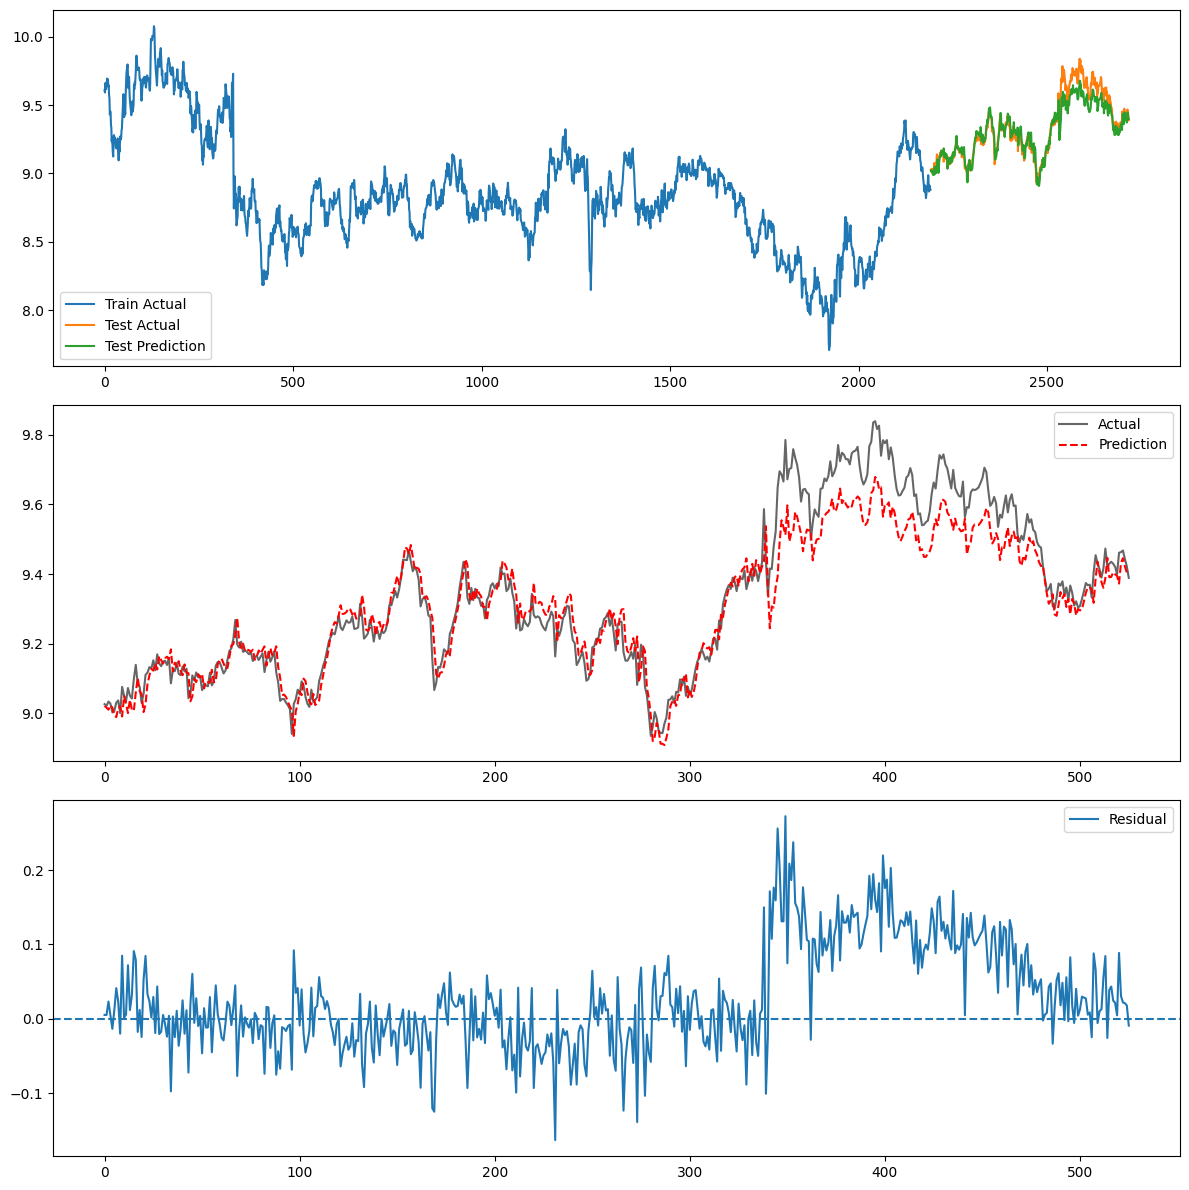

In [ ]:
from fx_forecasting.training.evaluate import evaluate_model
from fx_forecasting.visualization.plots import plot_predictions
from fx_forecasting.data.preprocess import inverse_transform_target


preds, targets, metrics = evaluate_model(
    model,
    val_loader,
    device=device
)

# inverse transform
preds_original = inverse_transform_target(
    preds,
    scaler=scaler,
    columns=feature_columns,
    target_col=TARGET,
)

targets_original = inverse_transform_target(
    targets,
    scaler=scaler,
    columns=feature_columns,
    target_col=TARGET,
)

y_train_original = inverse_transform_target(
    y_train,
    scaler=scaler,
    columns=feature_columns,
    target_col=TARGET,
)

plot_predictions(
    preds=preds_original,
    targets=targets_original,
    train_targets=y_train_original
)